In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sharedfunctions import loadKernels, computeSigma, computeMagnitudeResponse, calculateEcc, eccL2Distance, eccWassersteinDistance, IDXROBUST, IDXVULNERABLE, GRIDSIZE, SIGMAGRID, NTHRESH, CSVPATH


In [2]:
kernels = loadKernels(CSVPATH)

In [3]:
def simulateDeeperLayerKernels(layer1Kernels, layeridx, seed):
    np.random.seed(seed)
    n = len(layer1Kernels)
    scale = 1.0 + layeridx * 0.15
    noise = np.random.randn(n, 3, 3) * 0.08 * scale
    base  = np.array([[1, 0, -1],[2, 0, -2],[1, 0, -1]], dtype=np.float32) * 0.05 * layeridx
    return (noise + base[np.newaxis]).astype(np.float32)


In [4]:
layerNames   = ["Layer 1\n(Real Data)", "Layer 2\n(Simulated)",
                 "Layer 3\n(Simulated)", "Layer 4\n(Simulated)"]
layerKernels = [kernels] + [simulateDeeperLayerKernels(kernels, i, 42+i)
                              for i in range(1, 4)]
layerSigmas  = []
for i, lk in enumerate(layerKernels):
    sigs = np.array([computeSigma(h) for h in lk])
    layerSigmas.append(sigs)
    pctCrit = 100 * np.mean(sigs < 0.01)
    print(f"{layerNames[i].replace(chr(10), ' ')}: "
          f"mean_sigma={np.mean(sigs):.5f}  "
          f"% critical (sigma<0.01): {pctCrit:.1f}%")


Layer 1 (Real Data): mean_sigma=0.00711  % critical (sigma<0.01): 86.9%
Layer 2 (Simulated): mean_sigma=0.01574  % critical (sigma<0.01): 39.2%
Layer 3 (Simulated): mean_sigma=0.02029  % critical (sigma<0.01): 29.5%
Layer 4 (Simulated): mean_sigma=0.02455  % critical (sigma<0.01): 23.8%


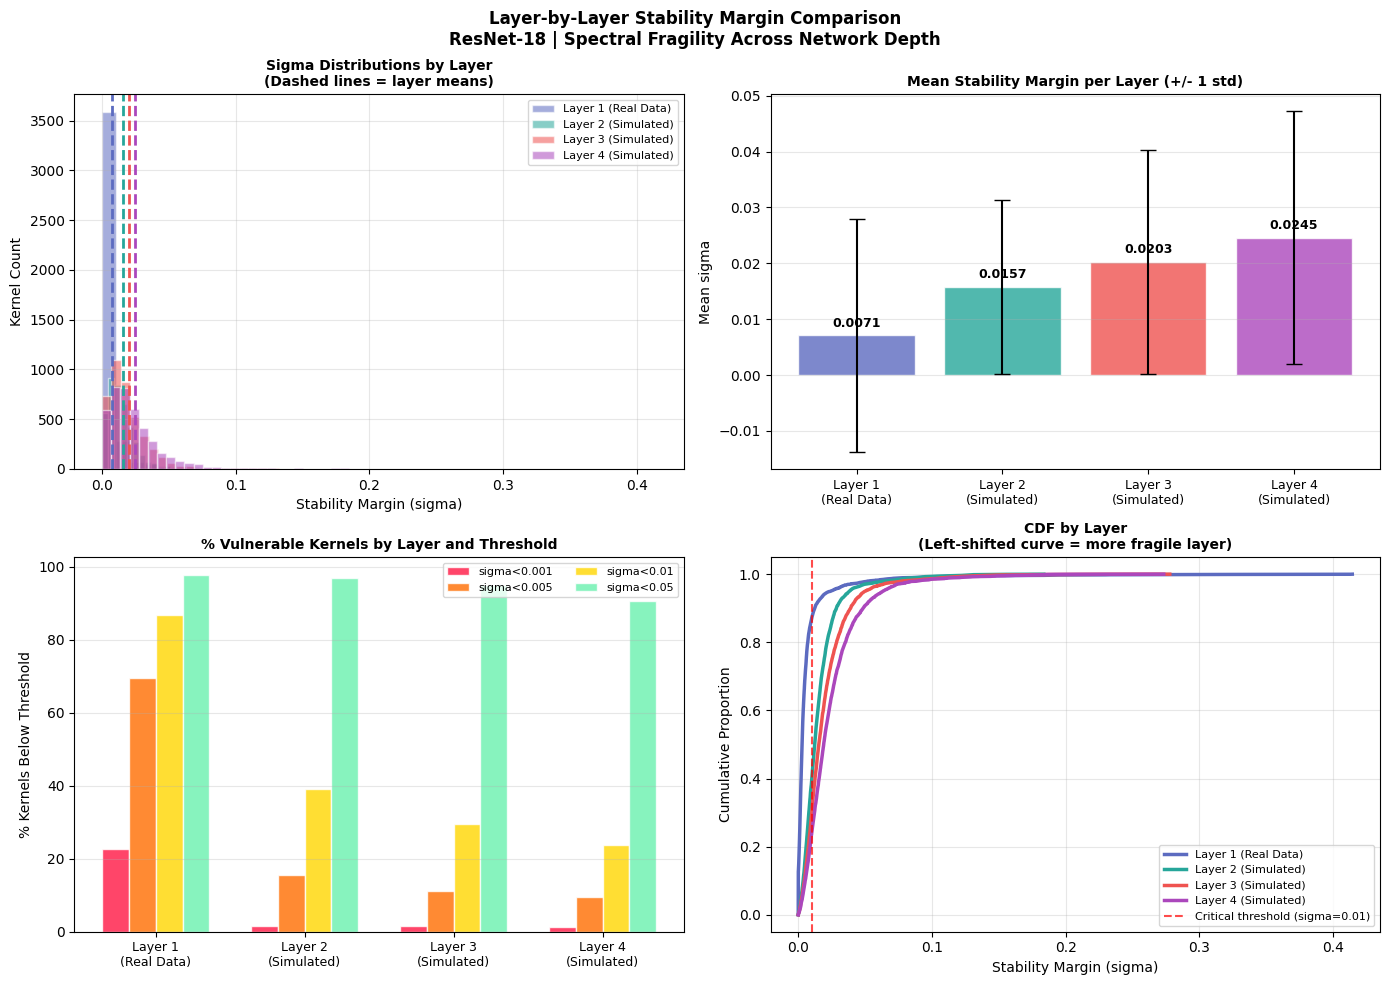

In [5]:
colors = ['#5c6bc0', '#26a69a', '#ef5350', '#ab47bc']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Layer-by-Layer Stability Margin Comparison\n"
             "ResNet-18 | Spectral Fragility Across Network Depth",
             fontsize=12, fontweight='bold')

ax = axes[0, 0]
for sigs, name, col in zip(layerSigmas, layerNames, colors):
    ax.hist(sigs, bins=40, alpha=0.55, color=col,
            label=name.replace('\n', ' '), edgecolor='white')
    ax.axvline(np.mean(sigs), color=col, linewidth=2, linestyle='--')
ax.set_title("Sigma Distributions by Layer\n(Dashed lines = layer means)",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Stability Margin (sigma)", fontsize=10)
ax.set_ylabel("Kernel Count", fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
means = [np.mean(s) for s in layerSigmas]
stds  = [np.std(s)  for s in layerSigmas]
x     = np.arange(len(layerNames))
bars  = ax.bar(x, means, yerr=stds, color=colors, alpha=0.8,
               capsize=6, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([n.replace('\n', '\n') for n in layerNames], fontsize=9)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title("Mean Stability Margin per Layer (+/- 1 std)",
             fontsize=10, fontweight='bold')
ax.set_ylabel("Mean sigma", fontsize=10)
ax.grid(True, alpha=0.3, axis='y')


ax = axes[1, 0]
vuln_thresholds = [0.001, 0.005, 0.01, 0.05]
thresh_colors   = ['#ff1744', '#ff6d00', '#ffd600', '#69f0ae']
width = 0.18
for j, (thr, tc) in enumerate(zip(vuln_thresholds, thresh_colors)):
    pcts = [100 * np.mean(s < thr) for s in layerSigmas]
    ax.bar(x + j*width - 0.27, pcts, width, color=tc, alpha=0.8,
           label=f'sigma<{thr}', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([n.replace('\n', '\n') for n in layerNames], fontsize=9)
ax.set_title("% Vulnerable Kernels by Layer and Threshold",
             fontsize=10, fontweight='bold')
ax.set_ylabel("% Kernels Below Threshold", fontsize=10)
ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
for sigs, name, col in zip(layerSigmas, layerNames, colors):
    ss  = np.sort(sigs)
    cdf = np.arange(1, len(ss)+1) / len(ss)
    ax.plot(ss, cdf, color=col, linewidth=2.5, label=name.replace('\n', ' '))
ax.axvline(0.01, color='red', linewidth=1.5, linestyle='--', alpha=0.7,
           label='Critical threshold (sigma=0.01)')
ax.set_title("CDF by Layer\n(Left-shifted curve = more fragile layer)",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Stability Margin (sigma)", fontsize=10)
ax.set_ylabel("Cumulative Proportion", fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("LayerComparison.png", dpi=150, bbox_inches='tight')
plt.show()